# **Ateliê Generativo — Treinamento LoRA (Google Colab / GPU T4)**

> Notebook-guia da Etapa 2. Treina o adaptador LoRA de pixel art 16 bits.
Antes de começar: Runtime → Alterar tipo de runtime → GPUs (T4).

**1 - Infraestrutura, Otimização e Armazenamento Persistente**

In [1]:
# Célula 1: Montagem do Drive e Instalação do Ecossistema
from google.colab import drive
drive.mount('/content/drive')

import os
# Cria o diretório de destino no seu Google Drive
drive_path = "/content/drive/MyDrive/Atelie_Generativo_LoRA"
os.makedirs(drive_path, exist_ok=True)
print(f"📁 Pasta de salvamento criada em: {drive_path}")

# Instalação das bibliotecas com versões otimizadas para GPU T4
!pip install -q -U transformers accelerate peft bitsandbytes datasets xformers torchao

# Instalação da biblioteca diffusers (cutting-edge)
!pip install -q git+https://github.com/huggingface/diffusers.git

# Clonagem do repositório oficial da Hugging Face para acesso ao script de treinamento
!git clone https://github.com/huggingface/diffusers.git

Mounted at /content/drive
📁 Pasta de salvamento criada em: /content/drive/MyDrive/Atelie_Generativo_LoRA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Cloning into 'diffusers'...
remote: Enumerating objects: 126139, done.
remote: Counting objects: 100% (948/948), done.
remote: Compressing objects: 100% (549/549), done.
remote: Total 126139 (delta 740), reused 399 (delta 399), pack-reused 125191 (from 4)
Receiving objects: 100% (12613

**2 - Ingestão de Dados e Mapeamento de Caminhos**

In [2]:
# Célula 2: Download do Dataset e Construção do metadata.jsonl
import json

# Clona o repositório da equipe
!git clone https://github.com/Thiagofariasl/atelie-generativo-estilo-pixel-art.git

# Definição dos caminhos base
dataset_dir = "/content/atelie-generativo-estilo-pixel-art/dataset"
txt_file = os.path.join(dataset_dir, "legendas.txt")
jsonl_file = os.path.join(dataset_dir, "metadata.jsonl")

# Lógica de conversão adaptada para a arquitetura do GitHub
# Transforma: "img_01.jpg: legenda" -> {"file_name": "images/img_01.jpg", "text": "legenda"}
with open(txt_file, 'r', encoding='utf-8') as f_in, open(jsonl_file, 'w', encoding='utf-8') as f_out:
    for linha in f_in:
        if ':' in linha:
            arquivo, legenda = linha.split(':', 1)

            # Adicionando o prefixo da subpasta para garantir que o Diffusers encontre a imagem
            caminho_relativo = f"images/{arquivo.strip()}"

            json_obj = {"file_name": caminho_relativo, "text": legenda.strip()}
            f_out.write(json.dumps(json_obj) + '\n')

print("✅ Dataset preparado! O arquivo metadata.jsonl mapeia corretamente a subpasta 'images/'.")

Cloning into 'atelie-generativo-estilo-pixel-art'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (257/257), done.
remote: Total 274 (delta 80), reused 151 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (274/274), 23.34 MiB | 16.56 MiB/s, done.
Resolving deltas: 100% (80/80), done.
✅ Dataset preparado! O arquivo metadata.jsonl mapeia corretamente a subpasta 'images/'.


**3 - Configuração do Accelerate**

In [3]:
# Célula 3: Configuração do hardware
from accelerate.utils import write_basic_config
write_basic_config()
print("🚀 Accelerate configurado para maximizar a eficiência da GPU T4!")

🚀 Accelerate configurado para maximizar a eficiência da GPU T4!


**4 - O Treinamento Matemático (As Duas Configurações Exigidas)**

> Execute a Célula 4A, aguarde terminar (pode levar 20-40 min dependendo do número de épocas/imagens). Quando concluir, execute a 4B.

In [4]:
# Célula 4A: CONFIGURAÇÃO A (Rank 8) - Generalização de Estilo
!accelerate launch diffusers/examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="/content/atelie-generativo-estilo-pixel-art/dataset" \
  --dataloader_num_workers=8 \
  --resolution=512 \
  --center_crop \
  --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1000 \
  --learning_rate=1e-04 \
  --max_grad_norm=1 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=0 \
  --output_dir="/content/drive/MyDrive/Atelie_Generativo_LoRA/PixelArt_Rank8" \
  --checkpointing_steps=500 \
  --seed=42 \
  --rank=8 \
  --mixed_precision="fp16" \
  --enable_xformers_memory_efficient_attention

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
06/29/2026 21:42:37 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type:

In [5]:
# Célula 4B: CONFIGURAÇÃO B (Rank 32) - Alta Fidelidade de Detalhes
!accelerate launch diffusers/examples/text_to_image/train_text_to_image_lora.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --dataset_name="/content/atelie-generativo-estilo-pixel-art/dataset" \
  --dataloader_num_workers=8 \
  --resolution=512 \
  --center_crop \
  --random_flip \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1200 \
  --learning_rate=1e-04 \
  --max_grad_norm=1 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=0 \
  --output_dir="/content/drive/MyDrive/Atelie_Generativo_LoRA/PixelArt_Rank32" \
  --checkpointing_steps=500 \
  --seed=42 \
  --rank=32 \
  --mixed_precision="fp16" \
  --enable_xformers_memory_efficient_attention

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
06/29/2026 22:10:51 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type:

**5 - Inferência e Validação Visual**

> Após o treino, os arquivos *.safetensors* dos seus LoRAs estarão a salvo no seu Google Drive. Use esta célula para carregar o modelo treinado e testar se ele aprendeu o estilo!



Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


🎨 Sintetizando imagem no espaço latente...


  0%|          | 0/200 [00:00<?, ?it/s]


✨ Resultado da Inferência:


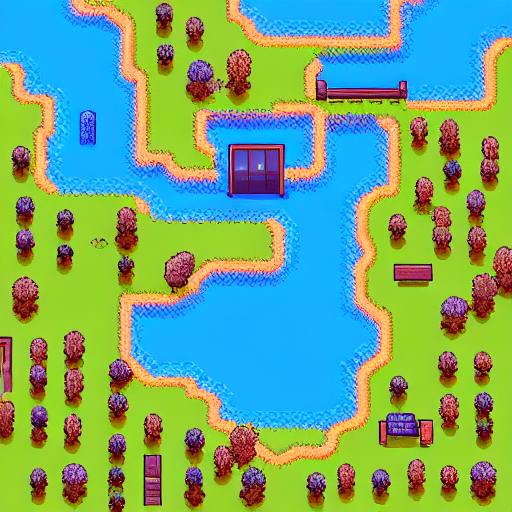

In [6]:
# Célula 5: Teste de Geração e Validação Visual
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display # Importação vital para renderizar imagens no Colab

# 1. Carrega o modelo fundacional em precisão de 16-bits para caber na GPU
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16)
pipe.to("cuda")

# 2. Injeta os pesos do seu LoRA treinado (Vamos testar o Rank 32)
caminho_do_lora = "/content/drive/MyDrive/Atelie_Generativo_LoRA/PixelArt_Rank32"
pipe.load_lora_weights(caminho_do_lora)

# 3. Geração no Espaço Latente
prompt = "estilo_pixel_art, cena em pixel art com uma fazenda, pomar de frutas e um lago azul."

print("🎨 Sintetizando imagem no espaço latente...")
imagem = pipe(prompt, num_inference_steps=200, guidance_scale=9.0).images[0]

# 4. Exibe o resultado visualmente dentro do Colab!
print("\n✨ Resultado da Inferência:")
display(imagem)